In [16]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
# If you're running the notebook from a subfolder, walk up until we find "data"
while not (PROJECT_ROOT / "data").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [103]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt

from src.copula import fit_copula_to_empirical_data
from src.copula.archimedean import (Gumbel, Clayton, Frank, Joe, N13, N14)
from src.copula.elliptical import (StudentCopula, GaussianCopula)
from src.copula.elliptical import fit_nu_for_t_copula
import  src.copula.copula_calculation as ccalc

from src.trading.copula_basic_rules import BasicCopulaTradingRule
from src.trading.copula_mpi import MPICopulaTradingRule

### Lecture Notes
https://www.youtube.com/watch?v=hLV5Roa_Bek&list=PLfv9eTYgatm0YJe9VCY1qLwj_dL9WWNn5&index=8

### Gumbell

In [10]:
cop = Gumbel(theta=2)

descr = cop.describe()
descr

Descriptive Name    Bivariate Gumbel Copula
Class Name                           Gumbel
theta                                     2
dtype: object

In [15]:
# Get cdf, pdf, conditional cdf
cdf = cop.get_cop_density(0.5, 0.7)
pdf = cop.get_cop_eval(0.5, 0.7)
cond_cdf = cop.get_condi_prob(0.5, 0.7)

# Sample from copula
sample = cop.sample(num=100)

# Fit copula to some data
cop.fit([0.5, 0.2, 0.3, 0.2, 0.1, 0.99],
        [0.1, 0.02, 0.9, 0.22, 0.11, 0.79])

print(cop.theta)

1.3812654999214318


<string>:9: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.



<Axes: title={'center': 'Scatter/heat plot for generated copula samples.'}>

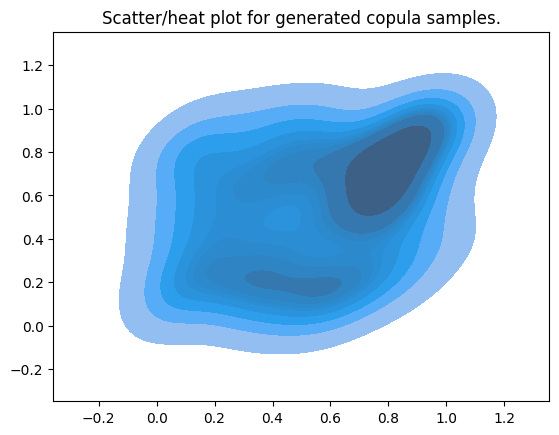

In [17]:
cop.plot_scatter(200)

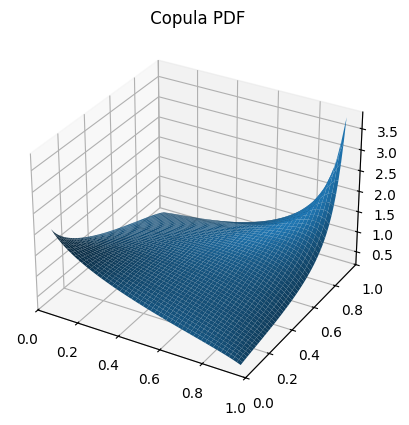

In [27]:
cop.plot_pdf('3d');
# cop.plot_pdf('contour');

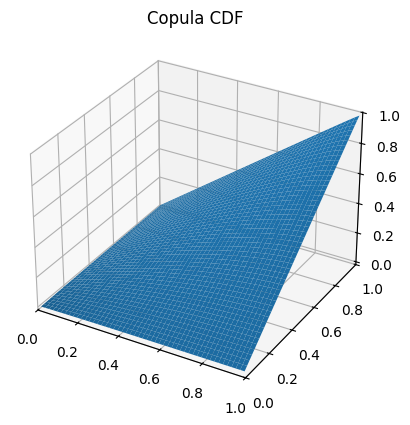

In [29]:
cop.plot_cdf('3d');
# cop.plot_cdf('contour')

### Student T

In [10]:
# Creating Student copula
nu = fit_nu_for_t_copula([0.5, 0.2, 0.3, 0.2, 0.1, 0.99],
                         [0.1, 0.02, 0.9, 0.22, 0.11, 0.79])

student_cop = StudentCopula(nu=nu, cov=None)
student_cop.fit([0.5, 0.2, 0.3, 0.2, 0.1, 0.99],
                [0.1, 0.02, 0.9, 0.22, 0.11, 0.79])

np.float64(0.5270170740230071)

### Fitting Data to Copula

In [41]:
data = pd.read_csv('../data/sample-data/BKD_ESC_2008_2009_June.csv', index_col=0)

bkd_prices = data[['BKD']]
esc_prices = data[['ESC']]

bkd_returns = bkd_prices.pct_change().dropna()
esc_returns = esc_prices.pct_change().dropna()

len(bkd_returns), len(esc_returns)

(376, 376)

In [44]:
# All Archimedean and Elliptical copulas to fit
copulas = [Gumbel, Clayton, Frank, Joe, N13, N14, GaussianCopula, StudentCopula]

aics = dict()

for cop in copulas:
    info_crit_logs, fit_copula, ecdf_x, ecdf_y = fit_copula_to_empirical_data(x = bkd_returns, y = esc_returns, copula=cop)
    aics[info_crit_logs['Copula Name']] = info_crit_logs['AIC']

# AIC values for all copulas
print(aics)

{'Gumbel': np.float64(-133.46809399802765), 'Clayton': np.float64(-151.61498948304302), 'Frank': np.float64(-154.79241679954913), 'Joe': np.float64(-47.61837011884017), 'N13': np.float64(-171.53798220071127), 'N14': np.float64(-174.81035712046767), 'Gaussian': np.float64(-159.882203348107), 'Student': np.float64(-170.60076431580006)}


## `BasicCopulaTradingRule`

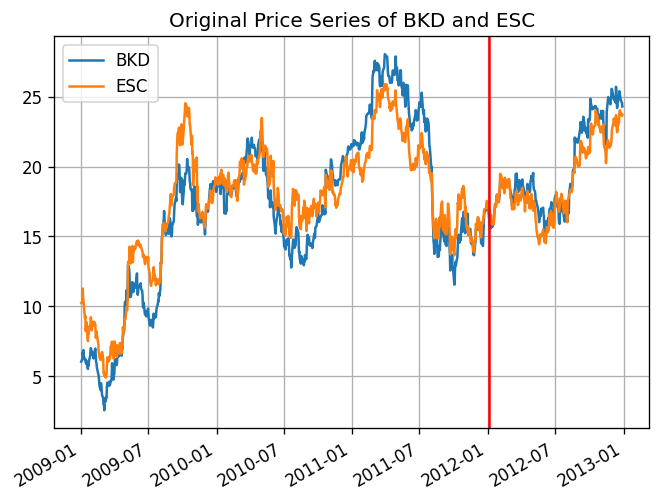

In [58]:
data = pd.read_csv('../data/sample-data/BKD_ESC_2009_2011.csv', index_col=0, parse_dates=True)

plt.figure(dpi=120)
plt.plot(data['BKD'], label='BKD')
plt.plot(data['ESC'], label='ESC')
plt.axvline(dt.date(2012, 1, 3), color='red')  # Training testing split date
plt.legend()
plt.grid()
plt.gcf().autofmt_xdate()
plt.title(r'Original Price Series of BKD and ESC')
plt.show()

In [59]:
BSC = BasicCopulaTradingRule()

# Training and testing split
training_length = 756 # From 01/02/2009 to 12/30/2011 (m/d/y)

prices_train = data.iloc[: training_length]
prices_test = data.iloc[training_length :]

# Empirical CDF for the training set.
# This step is only necessary for plotting.
cdf1 = ccalc.construct_ecdf_lin(prices_train['BKD'])
cdf2 = ccalc.construct_ecdf_lin(prices_train['ESC'])

In [60]:
# Fit different copulas, store the results in dictionaries
fit_result_gumbel, copula_gumbel, cdf_x_gumbel, cdf_y_gumbel =\
    ccalc.fit_copula_to_empirical_data(x=prices_train['BKD'], y=prices_train['ESC'], copula=Gumbel)

fit_result_frank, copula_frank, cdf_x_frank, cdf_y_frank =\
    ccalc.fit_copula_to_empirical_data(x=prices_train['BKD'], y=prices_train['ESC'], copula=Frank)

fit_result_clayton, copula_clayton, cdf_x_clayton, cdf_y_clayton =\
    ccalc.fit_copula_to_empirical_data(x=prices_train['BKD'], y=prices_train['ESC'], copula=Clayton)

fit_result_joe, copula_joe, cdf_x_joe, cdf_x_joe=\
    ccalc.fit_copula_to_empirical_data(x=prices_train['BKD'], y=prices_train['ESC'], copula=Joe)

fit_result_n14, copula_n14, cdf_x_n14, cdf_y_n14=\
    ccalc.fit_copula_to_empirical_data(x=prices_train['BKD'], y=prices_train['ESC'], copula=N14)

fit_result_gauss, copula_gauss, cdf_x_gauss, cdf_y_gauss =\
    ccalc.fit_copula_to_empirical_data(x=prices_train['BKD'], y=prices_train['ESC'], copula=GaussianCopula)

fit_result_t, copula_t, cdf_x_t, cdf_y_t=\
    ccalc.fit_copula_to_empirical_data(x=prices_train['BKD'], y=prices_train['ESC'], copula=StudentCopula)

In [61]:
# Print all the fit scores
print(fit_result_gumbel)
print(fit_result_frank)
print(fit_result_clayton)
print(fit_result_joe)
print(fit_result_n14)
print(fit_result_gauss)
print(fit_result_t)

{'Copula Name': 'Gumbel', 'SIC': np.float64(-1450.7952464332018), 'AIC': np.float64(-1455.4179827695934), 'HQIC': np.float64(-1453.6406691250231)}
{'Copula Name': 'Frank', 'SIC': np.float64(-1598.558975658291), 'AIC': np.float64(-1603.1817119946827), 'HQIC': np.float64(-1601.4043983501124)}
{'Copula Name': 'Clayton', 'SIC': np.float64(-1643.0112976940648), 'AIC': np.float64(-1647.6340340304564), 'HQIC': np.float64(-1645.856720385886)}
{'Copula Name': 'Joe', 'SIC': np.float64(-593.3513974013031), 'AIC': np.float64(-597.9741337376948), 'HQIC': np.float64(-596.1968200931245)}
{'Copula Name': 'N14', 'SIC': np.float64(-1555.5351104717956), 'AIC': np.float64(-1560.1578468081873), 'HQIC': np.float64(-1558.380533163617)}
{'Copula Name': 'Gaussian', 'SIC': np.float64(-1713.362919801625), 'AIC': np.float64(-1717.9856561380166), 'HQIC': np.float64(-1716.2083424934463)}
{'Copula Name': 'Student', 'SIC': np.float64(-1747.940642191169), 'AIC': np.float64(-1752.5633785275606), 'HQIC': np.float64(-175

In [63]:
# Print copula descriptions
print(copula_t.describe(), '\n')
print(copula_gauss.describe(), '\n')
print(copula_clayton.describe(), '\n')

Descriptive Name                                  Bivariate Student-t Copula
Class Name                                                           Student
cov                        [[1.6239798280267543, 1.5396000713622469], [1....
rho                                                                 0.949306
nu (degrees of freedom)                                                  6.0
dtype: object 

Descriptive Name                            Bivariate Gaussian Copula
Class Name                                                   Gaussian
cov                 [[1.0084515263499096, 0.9545064646064588], [0....
rho                                                          0.947212
dtype: object 

Descriptive Name    Bivariate Clayton Copula
Class Name                           Clayton
theta                               8.419491
dtype: object 



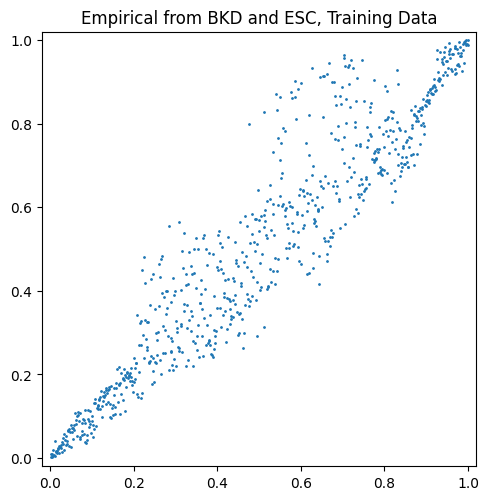

In [64]:
# Plotting copulas
fig, ax = plt.subplots(figsize=(5,7), dpi=100)

ax.scatter(prices_train['BKD'].apply(cdf1), prices_train['ESC'].apply(cdf2), s=1)
ax.set_aspect('equal', adjustable='box')
ax.set_title(r'Empirical from BKD and ESC, Training Data')
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
plt.tight_layout()

/Users/oriolripalta/Desktop/Projects/QuantTrading/src/copula/base.py:194: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  return theta_hat


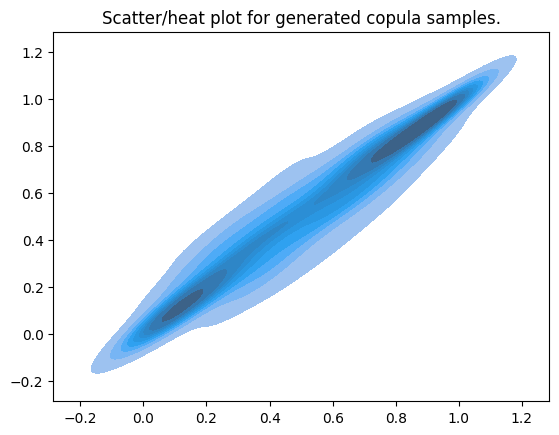

In [65]:
# N14
copula_n14.plot_scatter(num_points = training_length);

/Users/oriolripalta/Desktop/Projects/QuantTrading/src/copula/base.py:194: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  return theta_hat


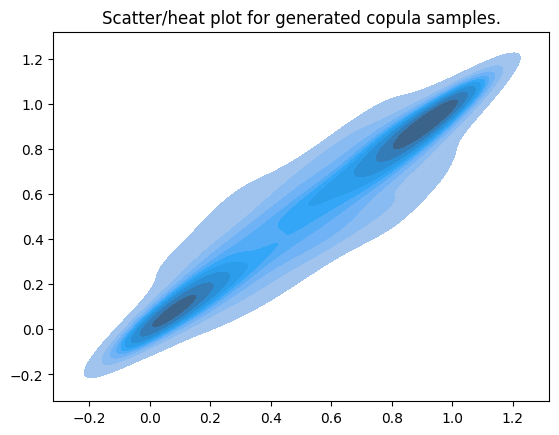

In [66]:
# Student-t
copula_t.plot_scatter(num_points = training_length);

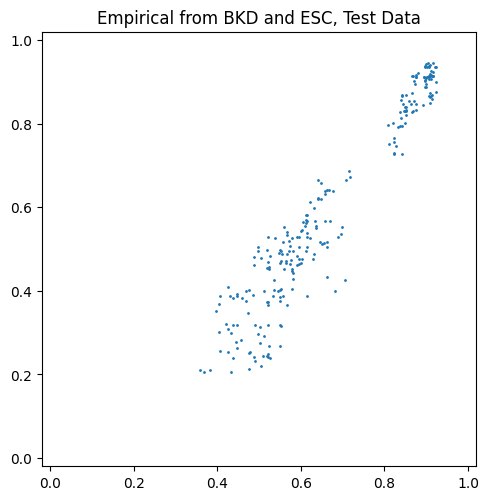

In [79]:
# Plotting copulas
fig, ax = plt.subplots(figsize=(5,7), dpi=100)

ax.scatter(prices_test['BKD'].map(cdf1), prices_test['ESC'].map(cdf2), s=1)
ax.set_aspect('equal', adjustable='box')
ax.set_title(r'Empirical from BKD and ESC, Test Data')
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
plt.tight_layout()

test_length = len(prices_test)

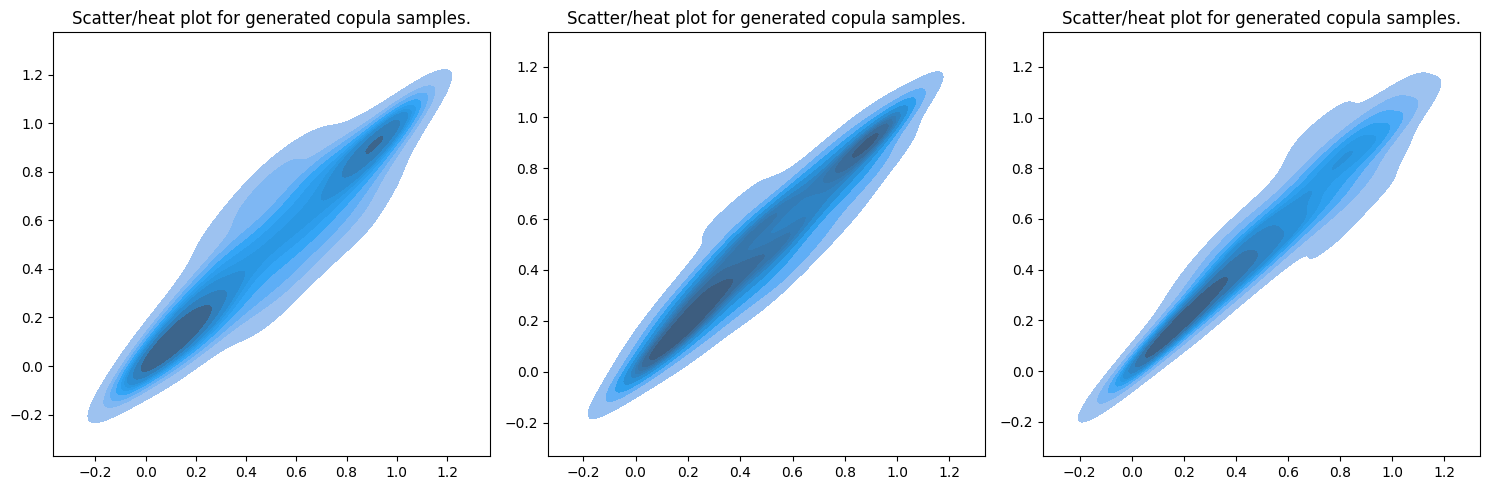

In [84]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# # Student-t
copula_t.plot_scatter(num_points = test_length, ax = axes[0]);

# # Gaussian
copula_gauss.plot_scatter(num_points = test_length, ax = axes[1]);

# Clayton
copula_clayton.plot_scatter(num_points = test_length, ax = axes[2]);

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">
<b>Note:</b> Although theoretically, one can change the threshold to potentially bring more trading opportunities, it needs to proceed with caution, as the recommended positions are very sensitive to the choice of copula and training data if the thresholds are not as strict. </div> 

### Trading Simulation 

As the trading strategy takes new observations one by one, we'll simulate such process.

So first we use the fitted copulas and CDFs to initialize trading strategies. Then we feed observations one by one, checking if the logic to open a long/short trade is triggered. If so, we take the trade and update the internal dictionary of the trading strategy class.

We also check if any of the currently open positions should be closed, and if so, we again update the internal dictionary.

In the end of the simulation we analyze the opened and closed positions during the period.

In [90]:
# Generate Trading Positions
# Using 'and' logic by default.

# ========== Use Student-t Copula ==========
# Instantiate the strategy
BCTR_t = BasicCopulaTradingRule(exit_rule='and', open_probabilities=(0.5, 0.95), exit_probabilities=(0.9, 0.5))
# Adding copula, cdf for X and Y to strategy
BCTR_t.set_copula(copula_t)
BCTR_t.set_cdf(cdf_x_t, cdf_y_t)
# Setting initial probabilities
BCTR_t.current_probabilities = (0.5, 0.5)

# ========== Use Gaussian Copula ==========
# Instantiate the strategy
BCTR_gauss = BasicCopulaTradingRule(exit_rule='and', open_probabilities=(0.5, 0.95), exit_probabilities=(0.9, 0.5))
# Adding copula, cdf for X and Y to strategy
BCTR_gauss.set_copula(copula_gauss)
BCTR_gauss.set_cdf(cdf_x_gauss, cdf_y_gauss)
# Setting initial probabilities
BCTR_gauss.current_probabilities = (0.5, 0.5)

# ========== Use Clayton Copula ==========
# Instantiate the strategy
BCTR_clayton = BasicCopulaTradingRule(exit_rule='and', open_probabilities=(0.5, 0.95), exit_probabilities=(0.9, 0.5))
# Adding copula, cdf for X and Y to strategy
BCTR_clayton.set_copula(copula_clayton)
BCTR_clayton.set_cdf(cdf_x_clayton, cdf_y_clayton)
# Setting initial probabilities
BCTR_clayton.current_probabilities = (0.5, 0.5)

# ========== Use Student-t Copula with 'or' logic ==========
# Instantiate the strategy
BCTR_t_or = BasicCopulaTradingRule(exit_rule='or', open_probabilities=(0.5, 0.95), exit_probabilities=(0.9, 0.5))
# Adding copula, cdf for X and Y to strategy
BCTR_t_or.set_copula(copula_t)
BCTR_t_or.set_cdf(cdf_x_t, cdf_y_t)
# Setting initial probabilities
BCTR_t_or.current_probabilities = (0.5, 0.5)

In [91]:
# Simulate trading process on test data for StudentCopula
for time, values in prices_test.iterrows():
    x_price = values['BKD']
    y_price = values['ESC']

    # Adding price values
    BCTR_t.update_probabilities(x_price, y_price)
    
    # Check if it's time to enter a trade
    trade, side = BCTR_t.check_entry_signal()

    # Close previous trades if needed
    BCTR_t.update_trades(update_timestamp=time)

    if trade:  # Open a new trade if needed
        BCTR_t.add_trade(start_timestamp=time, side_prediction=side)

# Finally, check open trades at the end of the simulation
open_trades_t = BCTR_t.open_trades

# And all trades that were opened and closed
closed_trades_t = BCTR_t.closed_trades

In [93]:
# No currently open trades
len(open_trades_t)

0

In [94]:
# And 22 trades were opened and closed during the testing period
len(closed_trades_t)

22

In [ ]:
# Simulate trading process on test data for StudentCopula
for time, values in prices_test.iterrows():
    x_price = values['BKD']
    y_price = values['ESC']

    # Adding price values
    BCTR_gauss.update_probabilities(x_price, y_price)
    BCTR_clayton.update_probabilities(x_price, y_price)
    BCTR_t_or.update_probabilities(x_price, y_price)
    
    # Check if it's time to enter a trade
    trade_gauss, side_gauss = BCTR_gauss.check_entry_signal()
    trade_clayton, side_clayton = BCTR_clayton.check_entry_signal()
    trade_t_or, side_t_or = BCTR_t_or.check_entry_signal()

    # Close previous trades if needed
    BCTR_gauss.update_trades(update_timestamp=time)
    BCTR_clayton.update_trades(update_timestamp=time)
    BCTR_t_or.update_trades(update_timestamp=time)

    if trade_gauss:  # Open a new trade if needed
        BCTR_gauss.add_trade(start_timestamp=time, side_prediction=side_gauss)
    if trade_clayton:  # Open a new trade if needed
        BCTR_clayton.add_trade(start_timestamp=time, side_prediction=side_clayton)
    if trade_t_or:  # Open a new trade if needed
        BCTR_t_or.add_trade(start_timestamp=time, side_prediction=side_t_or)
        
# Finally, check open trades at the end of the simulation
open_trades_gauss = BCTR_gauss.open_trades
open_trades_clayton = BCTR_clayton.open_trades
open_trades_t_or = BCTR_t_or.open_trades

# And all trades that were opened and closed
closed_trades_gauss = BCTR_gauss.closed_trades
closed_trades_clayton = BCTR_clayton.closed_trades
closed_trades_t_or = BCTR_t_or.closed_tradesb

### Strategy Output: Gauss

In [96]:
# Following a logic of one open trade at a time - using the first trade
open_time = list(closed_trades_gauss.keys())[0]
close_time = list(closed_trades_gauss.values())[0]['t1']
position = list(closed_trades_gauss.values())[0]['side']

# Creating dataframe for viaualization
positions_gauss = pd.DataFrame(0, index=prices_test.index, columns=['Gauss Positions'])
positions_gauss[(open_time < positions_gauss.index) & (positions_gauss.index< close_time)] = position

/var/folders/bc/hnzwjdn546lcc572zg36k_vc0000gn/T/ipykernel_24431/1415238168.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axs[0].plot((prices_test['BKD'] / prices_test['BKD'][0]).map(np.log), label='BKD', color='cornflowerblue')
/var/folders/bc/hnzwjdn546lcc572zg36k_vc0000gn/T/ipykernel_24431/1415238168.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axs[0].plot((prices_test['ESC'] / prices_test['ESC'][0]).map(np.log), label='ESC', color='seagreen')


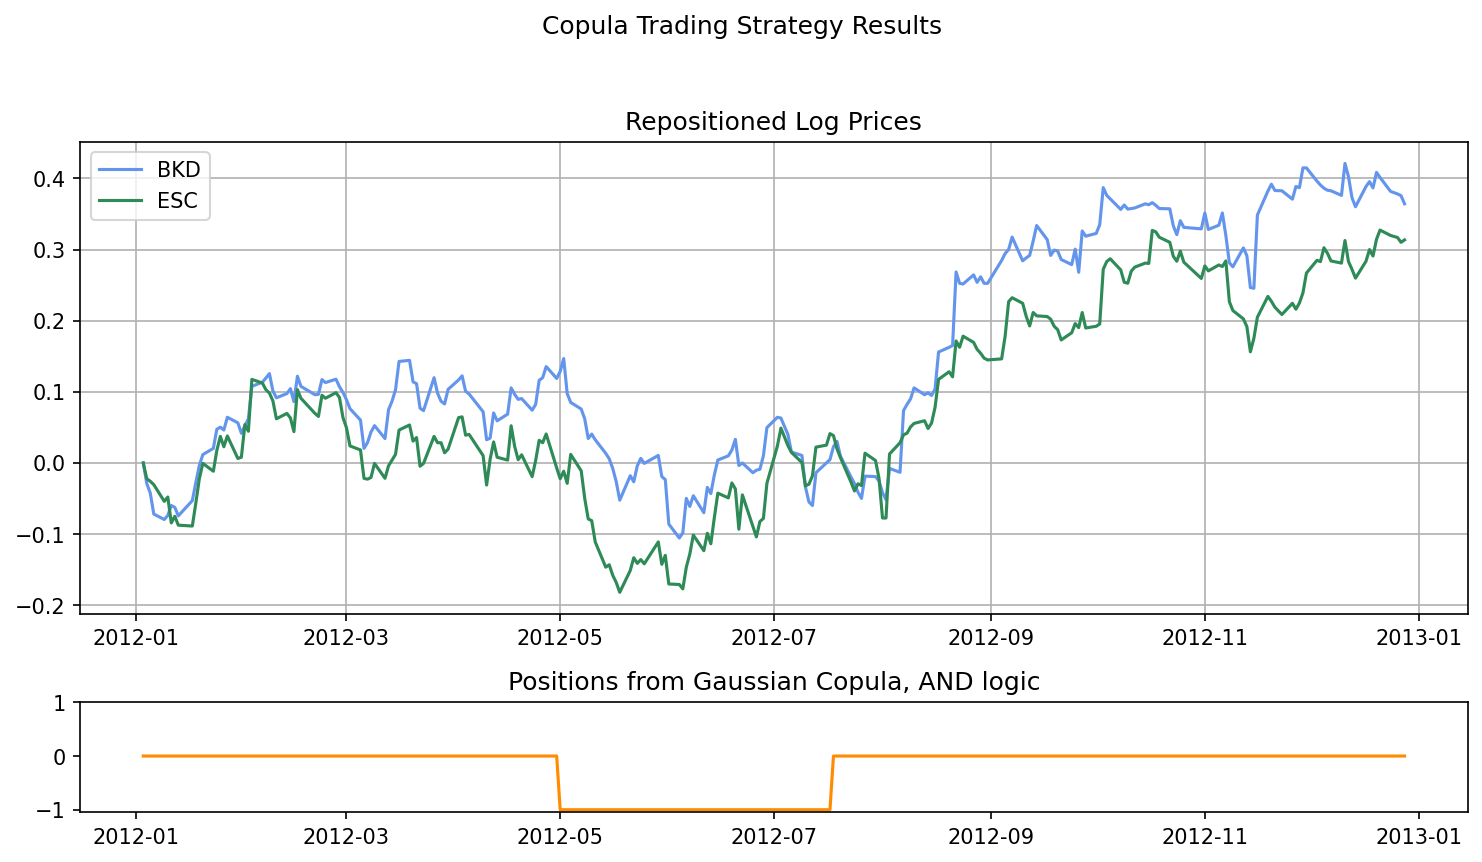

In [99]:
# Plotting generated positions
fig, axs = plt.subplots(2, 1, gridspec_kw={'height_ratios': [3, 0.7]}, figsize=(10,6), dpi=150)
fig.suptitle('Copula Trading Strategy Results')

# Plotting repositioned log prices
axs[0].plot((prices_test['BKD'] / prices_test['BKD'][0]).map(np.log), label='BKD', color='cornflowerblue')
axs[0].plot((prices_test['ESC'] / prices_test['ESC'][0]).map(np.log), label='ESC', color='seagreen')
axs[0].title.set_text('Repositioned Log Prices')
axs[0].legend()
axs[0].grid()

# Plotting position from Gaussian copula strategy
axs[1].plot(positions_gauss , label='Positions', color='darkorange')
axs[1].title.set_text('Positions from Gaussian Copula, AND logic')
axs[1].set_yticks([-1,0,1])

fig.tight_layout(rect=[0, 0.03, 1, 0.95])  # Avoid title overlap
plt.show()

In [100]:
# 1. Calculating weights
w1_star = -prices_test['ESC'][0] / (prices_test['BKD'][0] - prices_test['ESC'][0])
w2_star = w1_star - 1

w1 = w1_star / (w1_star + w2_star)
w2 = w2_star / (w1_star + w2_star)

print('Unnormalized weight: \n\
w1_star={}, \nw2_star={},\n\
Normalized weight:\n\
w1={} \nw2={}'.format(w1_star, w2_star, w1, w2))

Unnormalized weight: 
w1_star=39.363546901029885, 
w2_star=38.363546901029885,
Normalized weight:
w1=0.5064327633459872 
w2=0.4935672366540128


/var/folders/bc/hnzwjdn546lcc572zg36k_vc0000gn/T/ipykernel_24431/4248670338.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  w1_star = -prices_test['ESC'][0] / (prices_test['BKD'][0] - prices_test['ESC'][0])


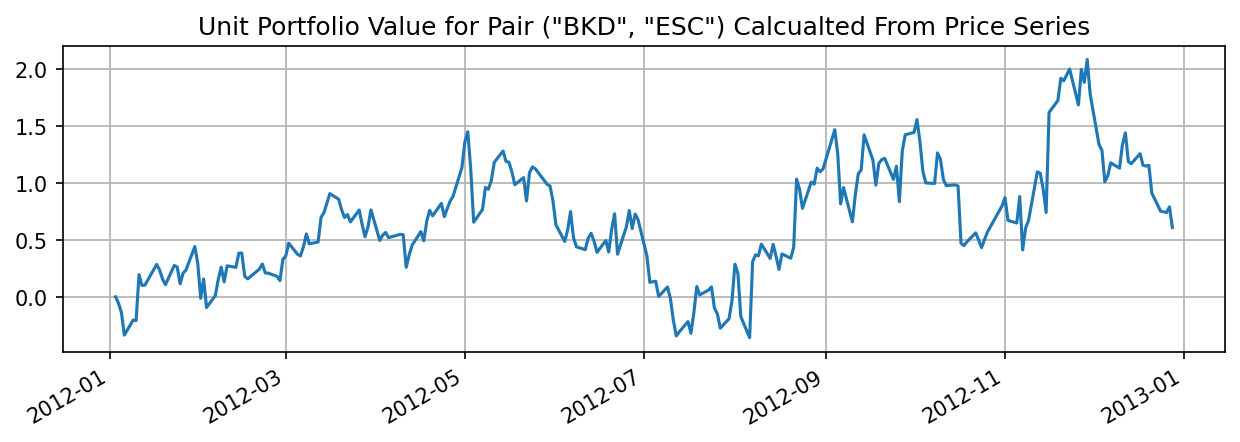

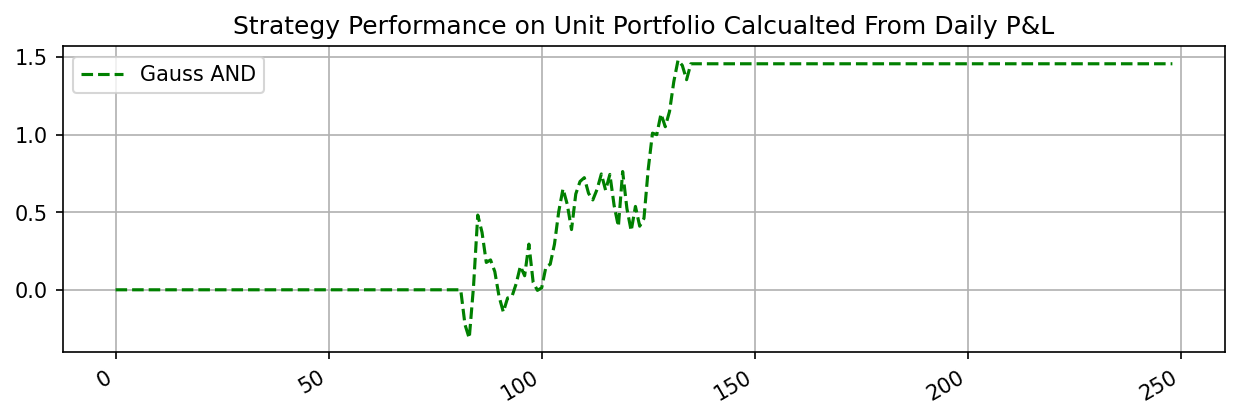

In [101]:
# 2. Calculating Portfolio Series and daily P&L
portfolio_prices = w1 * prices_test['BKD'] - w2 * prices_test['ESC']
portfolio_pnl = np.diff(portfolio_prices, prepend=0)

# 3. Plotting portfolio prices
fig, ax = plt.subplots(figsize=(10,3), dpi=150)
ax.plot(portfolio_prices)
ax.title.set_text('Unit Portfolio Value for Pair ("BKD", "ESC") Calcualted From Price Series')
ax.grid()
fig.autofmt_xdate()
plt.show()

# 4. Calculating strategy daily P&L
pnl_gauss = portfolio_pnl * positions_gauss.values.T
equity_gauss = pnl_gauss.cumsum()

fig, ax = plt.subplots(figsize=(10,3), dpi=150)
ax.plot(equity_gauss, '--', color='g',label=r'Gauss AND')
ax.title.set_text('Strategy Performance on Unit Portfolio Calcualted From Daily P&L')
ax.grid()
fig.autofmt_xdate()
ax.legend()
plt.show()

## `MispricingIndexCopulaTradingRule`

### Trading Simulation

In [138]:
# Make two strategy classes with the fitted Student and N14 copula.
CSMPI_t = MPICopulaTradingRule(opening_triggers=(-0.2, 0.2), stop_loss_positions=(-2, 2))
CSMPI_t.set_copula(copula_t)
CSMPI_t.set_cdf(cdf_x_t, cdf_y_t)

CSMPI_n14 = MPICopulaTradingRule(opening_triggers=(-0.5, 0.5), stop_loss_positions=(-2.1, 2.1))
CSMPI_n14.set_copula(copula_n14)
CSMPI_n14.set_cdf(cdf_x_n14, cdf_y_n14)

returns_test = CSMPI_t.to_returns(prices_test)

# Get positions and flag series
positions_t, flags_t = CSMPI_t.get_positions_and_flags(returns = returns_test, enable_reset_flag=True)
positions_n14, flags_n14 = CSMPI_n14.get_positions_and_flags(returns = returns_test, enable_reset_flag=True, open_rule='and', exit_rule='or')

# Shift the positions by 1 day
positions_t = positions_t.shift(1)
positions_n14 = positions_n14.shift(1)
positions_t[0] = 0
positions_n14[0] = 0

/Users/oriolripalta/Desktop/Projects/QuantTrading/src/trading/copula_mpi.py:133: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  condi_probs.iloc[row_count] = [self.copula.get_condi_prob(row[1][0], row[1][1]),
/Users/oriolripalta/Desktop/Projects/QuantTrading/src/trading/copula_mpi.py:134: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  self.copula.get_condi_prob(row[1][1], row[1][0])]
/Users/oriolripalta/Desktop/Projects/QuantTrading/src/trading/copula_mpi.py:248: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent wit

/var/folders/bc/hnzwjdn546lcc572zg36k_vc0000gn/T/ipykernel_24431/1998036343.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(prices_test['BKD'] / prices_test['BKD'][0], label='BKD prices')
/var/folders/bc/hnzwjdn546lcc572zg36k_vc0000gn/T/ipykernel_24431/1998036343.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(prices_test['ESC'] / prices_test['ESC'][0], label='ESC prices')


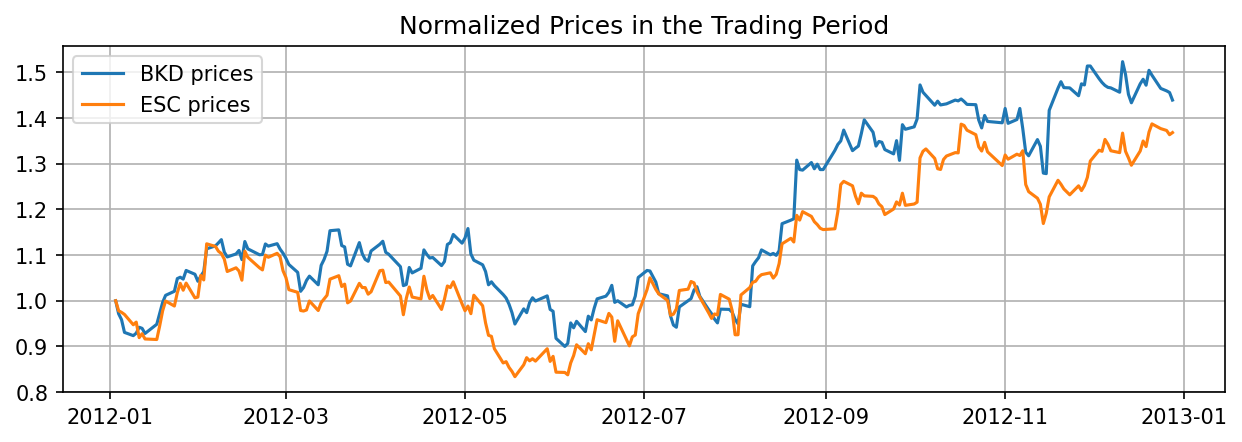

In [139]:
# As a referece we also plot the normalized price series from the two stocks.
plt.figure(figsize=(10, 3), dpi=150)
plt.plot(prices_test['BKD'] / prices_test['BKD'][0], label='BKD prices')
plt.plot(prices_test['ESC'] / prices_test['ESC'][0], label='ESC prices')
plt.title('Normalized Prices in the Trading Period')
plt.legend()
plt.grid()
plt.show()

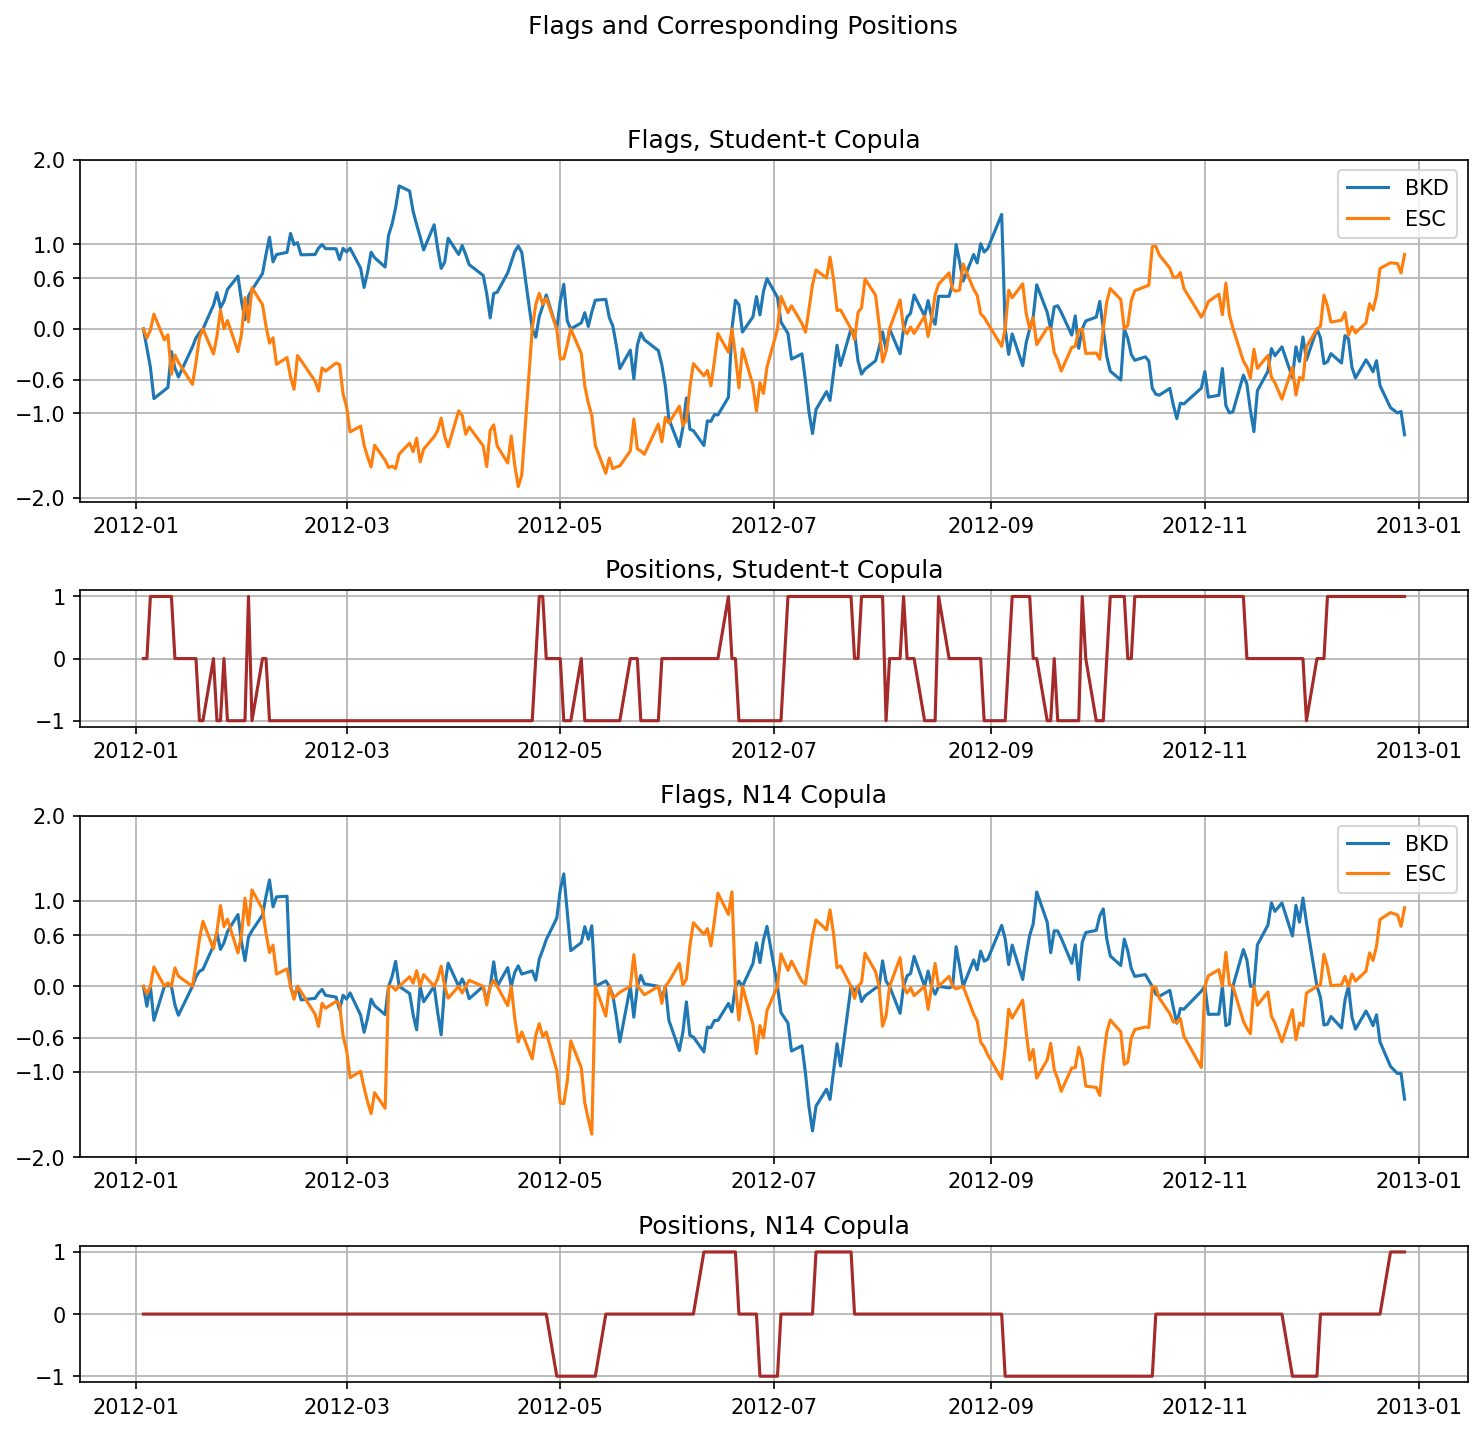

In [142]:
# Plot positions and flags
fig, axs = plt.subplots(4, 1, gridspec_kw={'height_ratios': [1, 0.4, 1, 0.4]}, figsize=(10,10), dpi=150)
fig.suptitle('Flags and Corresponding Positions')

# Plotting flags for Student-t copula
axs[0].plot(flags_t['BKD'], label='BKD')
axs[0].plot(flags_t['ESC'], label='ESC')
axs[0].title.set_text('Flags, Student-t Copula')
axs[0].legend()
axs[0].grid()
axs[0].set_yticks([-2, -1, -0.6, 0, 0.6, 1, 2])

# Plotting positions for Student-t copula
axs[1].plot(positions_t, label='Positions', color='brown')
axs[1].title.set_text('Positions, Student-t Copula')
axs[1].grid()
axs[1].set_yticks([-1,0,1])

# Plotting flags for N14 copula
axs[2].plot(flags_n14['BKD'], label='BKD')
axs[2].plot(flags_n14['ESC'], label='ESC')
axs[2].title.set_text('Flags, N14 Copula')
axs[2].legend()
axs[2].grid()
axs[2].set_yticks([-2, -1, -0.6, 0, 0.6, 1, 2])

# Plotting positions for N14 copula
axs[3].plot(positions_n14, label='Positions', color='brown')
axs[3].title.set_text('Positions, N14 Copula')
axs[3].grid()
axs[3].set_yticks([-1,0,1])

fig.tight_layout(rect=[0, 0.03, 1, 0.95])  # Avoid title overlap
plt.show()

/Users/oriolripalta/Desktop/Projects/QuantTrading/src/trading/copula_mpi.py:166: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  units_df.iloc[0, 0] = 0.5 / prices_df.iloc[0, 0] * positions[0]
/Users/oriolripalta/Desktop/Projects/QuantTrading/src/trading/copula_mpi.py:167: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  units_df.iloc[0, 1] = - 0.5 / prices_df.iloc[1, 0] * positions[0]
/Users/oriolripalta/Desktop/Projects/QuantTrading/src/trading/copula_mpi.py:174: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with

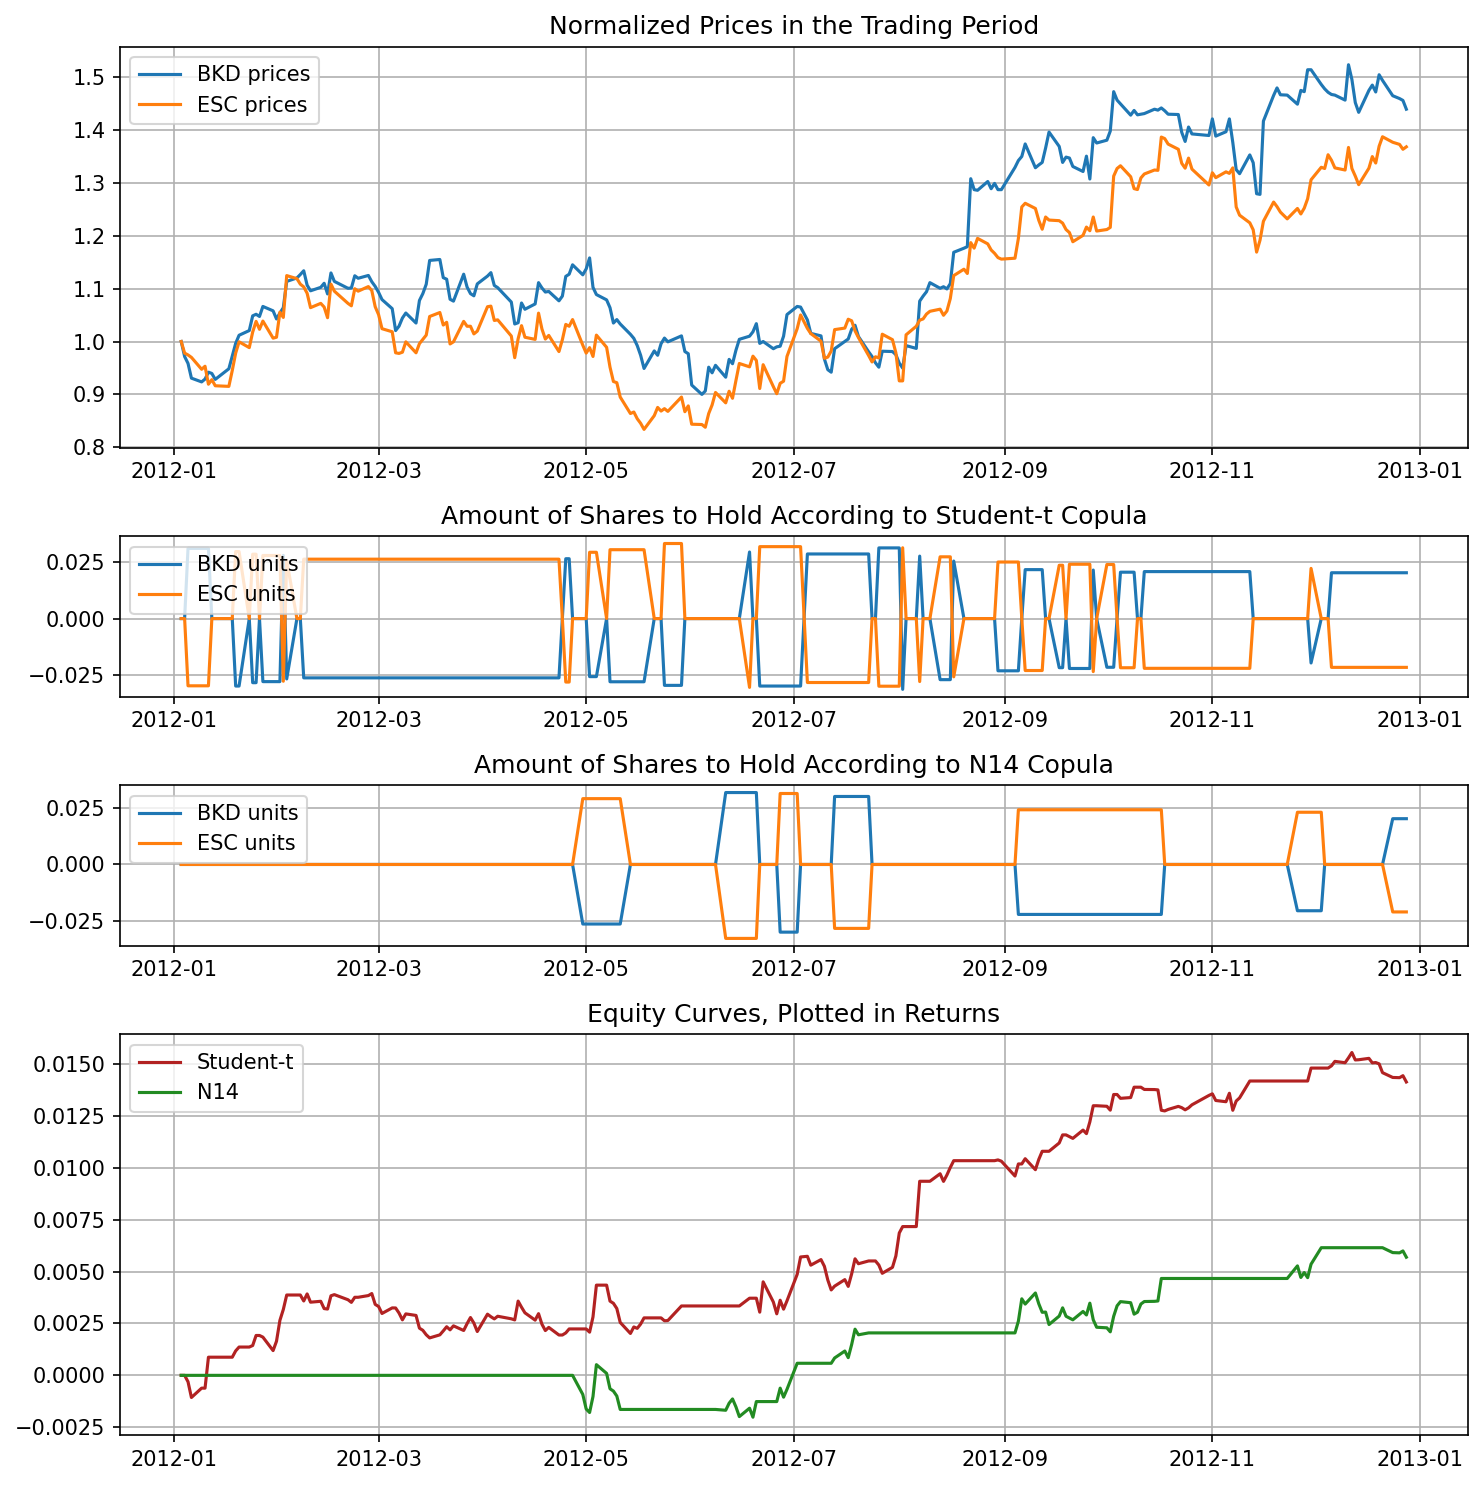

In [143]:
# 1. Calculate the unit holding series
units_df_t = CSMPI_t.positions_to_units_dollar_neutral(prices_df=prices_test, positions=positions_t)
units_df_n14 = CSMPI_n14.positions_to_units_dollar_neutral(prices_df=prices_test, positions=positions_n14)

# Calculate returns from the strategy, i.e., assuming 1$ initial investment and calculate P&L.
# 2. Calculate Daily P&L of the strategy based on the units holding for each security
portfolio_pnl_t = returns_test['BKD'] * units_df_t['BKD'] + returns_test['ESC'] * units_df_t['ESC']
portfolio_pnl_n14 = returns_test['BKD'] * units_df_n14['BKD'] + returns_test['ESC'] * units_df_n14['ESC']

# 3. Calculate and plot the equity curve
equity_t = portfolio_pnl_t.cumsum()
equity_n14 = portfolio_pnl_n14.cumsum()

# Plotting
fig, axs = plt.subplots(4, 1, gridspec_kw={'height_ratios': [0.5, 0.2, 0.2, 0.5]}, figsize=(10,10), dpi=150)

# As a referece we also plot the normalized price series from the two stocks.
axs[0].plot(prices_test['BKD'] / prices_test['BKD'][0], label='BKD prices')
axs[0].plot(prices_test['ESC'] / prices_test['ESC'][0], label='ESC prices')
axs[0].set_title('Normalized Prices in the Trading Period')
axs[0].legend()
axs[0].grid()

# Plot the units series
axs[1].plot(units_df_t['BKD'], label='BKD units')
axs[1].plot(units_df_t['ESC'], label='ESC units')
axs[1].set_title('Amount of Shares to Hold According to Student-t Copula')
axs[1].legend()
axs[1].grid()

axs[2].plot(units_df_n14['BKD'], label='BKD units')
axs[2].plot(units_df_n14['ESC'], label='ESC units')
axs[2].set_title('Amount of Shares to Hold According to N14 Copula')
axs[2].legend()
axs[2].grid()

# Plot the daily P&L
axs[3].plot(equity_t, label='Student-t', color='firebrick')
axs[3].plot(equity_n14, label='N14', color='forestgreen')
axs[3].set_title('Equity Curves, Plotted in Returns')
axs[3].legend()
axs[3].grid()

fig.tight_layout()
plt.show()

# Interesting Open Problems

1. Parametrically fit a Student-t and mixed copula.

2. Existence of statistical properties that justify two random variables to have an Archimedean copula (like one
   can justify a random variable is normal).

3. Take advantage of copula's ability to capture nonlinear dependencies but also adjust it for time series, so that
   the sequence of data coming in makes a difference.

4. Analysis on copulas when it is used on time series instead of independent draws. (For example, how different it is
   when working with the average :math:`\mu` on time series, compared to the average :math:`\mu` on a random variable?)

5. Adjust copulas so it can model when dependency structure changes with time.

6. All copulas we mentioned so far, "pure" or mixed, assume symmetry. It would be nice to see analysis on asymmetric pairs modeled
   by copula.